In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
sklearn.set_config(transform_output="pandas")
from sklearn.model_selection import train_test_split

In [28]:
df = pd.read_csv('train.csv')
df = df.drop_duplicates()

In [29]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [14]:
df.isna().count()

Id               1460
MSSubClass       1460
MSZoning         1460
LotFrontage      1460
LotArea          1460
                 ... 
MoSold           1460
YrSold           1460
SaleType         1460
SaleCondition    1460
SalePrice        1460
Length: 81, dtype: int64

In [23]:
X, y = df.drop('SalePrice', axis=1), df['SalePrice']
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2,  random_state=42)

In [25]:
num_features = X_train.select_dtypes(exclude='object')
cat_features = X_train.select_dtypes(include='object')

/tmp/ipykernel_22794/2252630046.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X_train.select_dtypes(include='object')


In [ ]:
scaler = ColumnTransformer(
    [
        ('scaling_num_columns', StandardScaler(), cat_features)
    ],
    verbose_feature_names_out = False,
    remainder = 'passthrough' 
)

In [31]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [37]:
drop_features = ['PoolQC', 'Alley', 'MiscFeature']

In [38]:
zero_counts = (df == 0).sum()
zero_counts = zero_counts[zero_counts > 0].sort_values(ascending=False)

In [46]:
df['BedroomAbvGr'].unique()

array([3, 4, 1, 2, 0, 5, 6, 8])

In [ ]:
zero_counts
#PoolArea - оставляем как есть, остальные значения площадь
#3SsnPorch - крыльцо/веранда оставляем как есть, остальные значения площадь
#LowQualFinSF - метраж плохой отделки
#MiscVal - Стоимость прочих особенностей


PoolArea         1453
3SsnPorch        1436
LowQualFinSF     1434
MiscVal          1408
BsmtHalfBath     1378
ScreenPorch      1344
BsmtFinSF2       1293
EnclosedPorch    1252
HalfBath          913
MasVnrArea        861
BsmtFullBath      856
2ndFlrSF          829
WoodDeckSF        761
Fireplaces        690
OpenPorchSF       656
BsmtFinSF1        467
BsmtUnfSF         118
GarageArea         81
GarageCars         81
TotalBsmtSF        37
FullBath            9
BedroomAbvGr        6
KitchenAbvGr        1
dtype: int64

In [44]:
zero_analysis = pd.DataFrame({
    'Column': [
        'BsmtHalfBath', 'ScreenPorch', 'BsmtFinSF2', 'EnclosedPorch', 
        'HalfBath', 'MasVnrArea', 'BsmtFullBath', '2ndFlrSF', 
        'WoodDeckSF', 'Fireplaces', 'OpenPorchSF', 'BsmtFinSF1', 
        'BsmtUnfSF', 'GarageArea', 'GarageCars', 'TotalBsmtSF', 
        'FullBath', 'BedroomAbvGr', 'KitchenAbvGr'
    ],
    'Zero_Count': [
        1378, 1344, 1293, 1252, 913, 861, 856, 829, 
        761, 690, 656, 467, 118, 81, 81, 37, 9, 6, 1
    ],
    'Category': [
        'Basement', 'Exterior', 'Basement', 'Exterior',
        'Rooms', 'Special', 'Basement', 'Structure',
        'Exterior', 'Rooms', 'Exterior', 'Basement',
        'Basement', 'Garage', 'Garage', 'Basement',
        'Rooms', 'Rooms', 'Rooms'
    ],
    'Meaning': [
        'Нет подвала', 'Нет экранированного крыльца', 'Нет подвала', 'Нет закрытого крыльца',
        'Нет половины ванной', 'Нет облицовки', 'Нет подвала', 'Нет второго этажа',
        'Нет террасы', 'Нет камина', 'Нет открытого крыльца', 'Нет подвала',
        'Нет подвала', 'Нет гаража', 'Нет гаража', 'Нет подвала',
        'Нет полных ванных', 'Нет спален', 'Нет кухонь'
    ]
})

# Процент от общего количества
zero_analysis['Percent'] = zero_analysis['Zero_Count'] / len(df) * 100
zero_analysis = zero_analysis.sort_values('Zero_Count', ascending=False)

print("\n" + "="*80)
print("ПОЛНЫЙ АНАЛИЗ НУЛЕЙ ПО КОЛОНКАМ")
print("="*80)
print(zero_analysis.to_string(index=False))


ПОЛНЫЙ АНАЛИЗ НУЛЕЙ ПО КОЛОНКАМ
       Column  Zero_Count  Category                     Meaning   Percent
 BsmtHalfBath        1378  Basement                 Нет подвала 94.383562
  ScreenPorch        1344  Exterior Нет экранированного крыльца 92.054795
   BsmtFinSF2        1293  Basement                 Нет подвала 88.561644
EnclosedPorch        1252  Exterior       Нет закрытого крыльца 85.753425
     HalfBath         913     Rooms         Нет половины ванной 62.534247
   MasVnrArea         861   Special               Нет облицовки 58.972603
 BsmtFullBath         856  Basement                 Нет подвала 58.630137
     2ndFlrSF         829 Structure           Нет второго этажа 56.780822
   WoodDeckSF         761  Exterior                 Нет террасы 52.123288
   Fireplaces         690     Rooms                  Нет камина 47.260274
  OpenPorchSF         656  Exterior       Нет открытого крыльца 44.931507
   BsmtFinSF1         467  Basement                 Нет подвала 31.986301
    B

In [ ]:
df['PoolArea']['']

array([  0, 512, 648, 576, 555, 480, 519, 738])

In [48]:
df['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [52]:
df['LogPrice'] = np.log1p(df['SalePrice'])

In [ ]:
sns.boxplot(data=df, x='Количество комнат', y = 'SalePrice')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()
print(df.groupby('Количество комнат')['Цена'].describe())

In [49]:
df['LotArea'].unique()

array([ 8450,  9600, 11250, ..., 17217, 13175,  9717], shape=(1073,))

In [54]:
recommended_columns = [
    'OverallQual',      # Общее качество (категориальный, но числовой)
    'GrLivArea',        # Жилая площадь
    'TotalBsmtSF',      # Площадь подвала
    'GarageArea',       # Площадь гаража
    'YearBuilt',        # Год постройки
    'LotArea',          # Площадь участка
    '1stFlrSF',         # Площадь первого этажа
    'FullBath',         # Количество ванных
    'Fireplaces',       # Количество каминов
    'MasVnrArea'        # Площадь облицовки
]

ValueError: Bin edges must be unique: Index([0.0, 0.0, 0.0, 16.0, 206.0, 1600.0], dtype='float64', name='MasVnrArea').
You can drop duplicate edges by setting the 'duplicates' kwarg

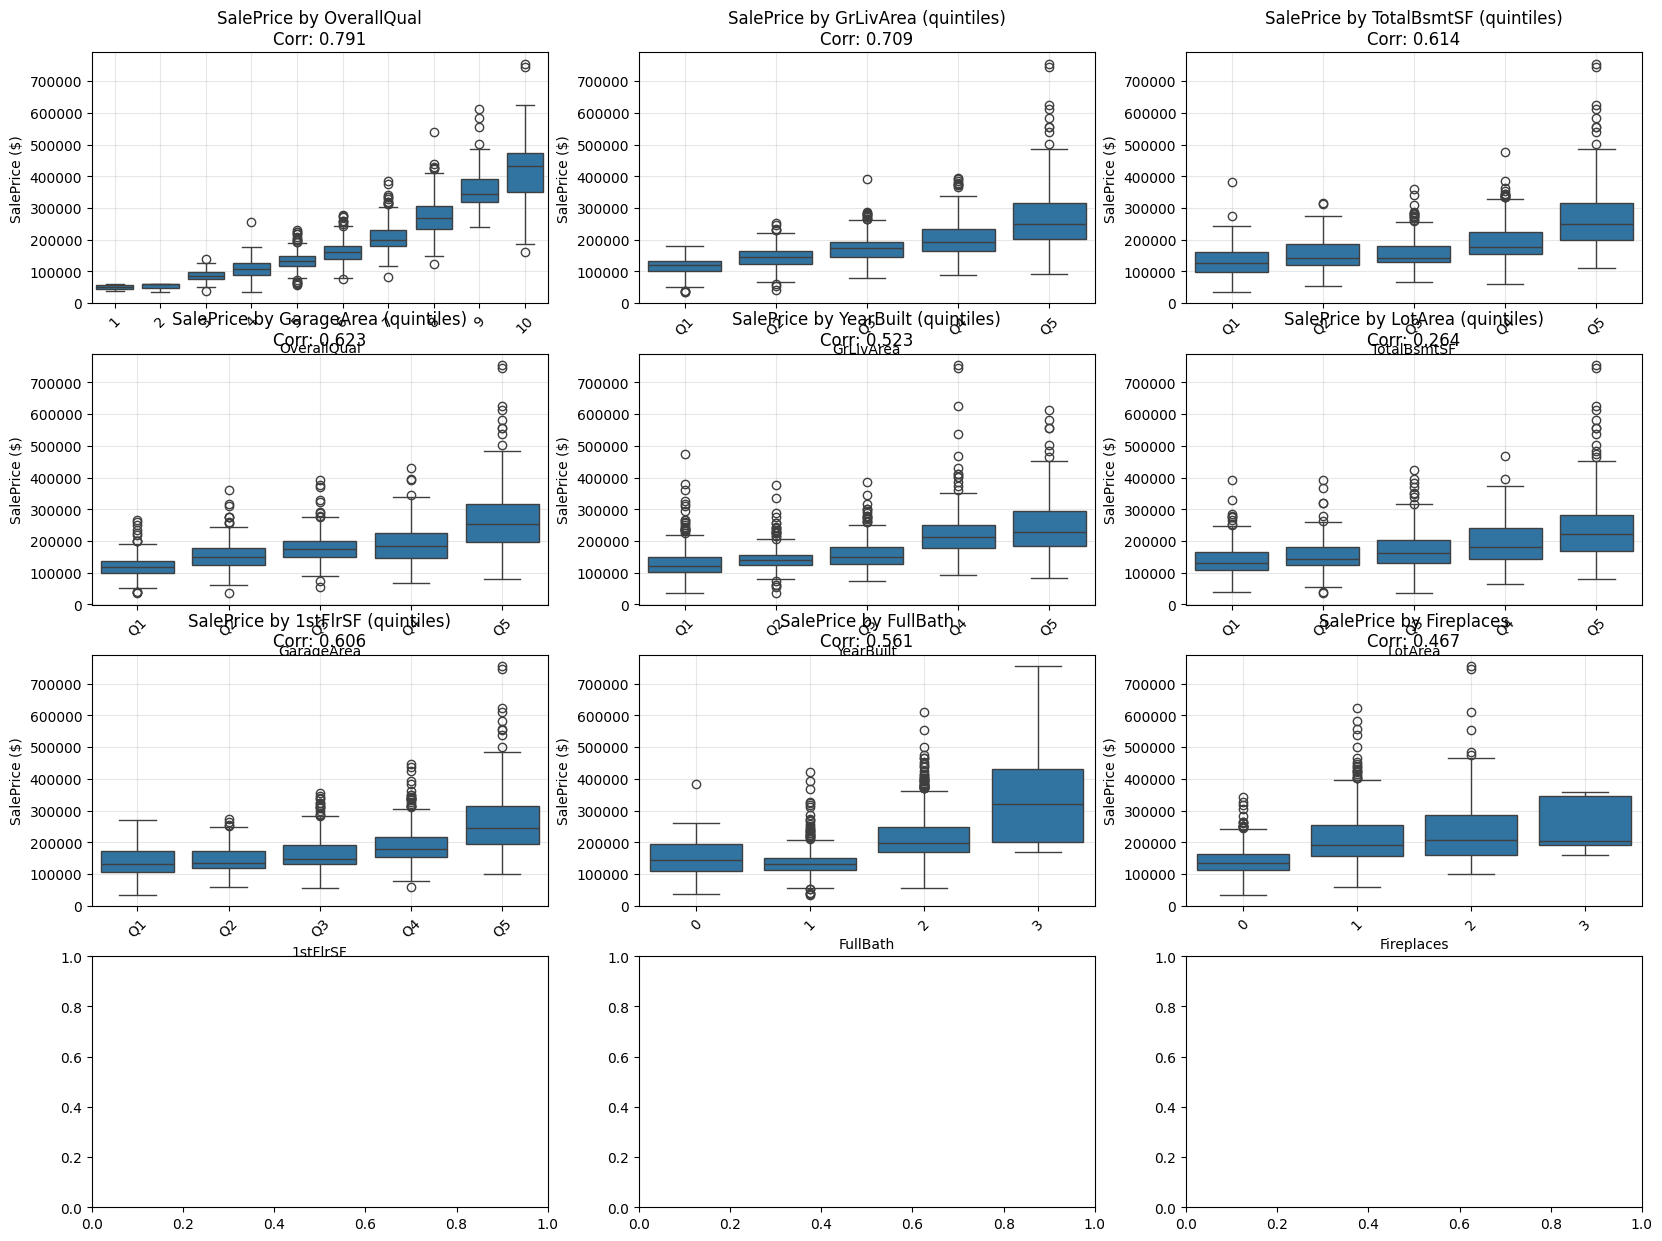

In [63]:
def plot_price_boxplots_by_features(df, features, figsize=(20, 15)):
    """
    Строит boxplot'ы цены по различным признакам для выявления выбросов
    """
    n_features = len(features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()
    
    for idx, feature in enumerate(features):
        if idx < len(axes):
            if feature in df.columns:
                # Определяем тип признака
                if df[feature].dtype in ['int64', 'float64'] and df[feature].nunique() > 20:
                    # Непрерывный признак - разбиваем на категории
                    df[f'{feature}_bin'] = pd.qcut(df[feature], q=5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])
                    sns.boxplot(data=df, x=f'{feature}_bin', y='SalePrice', ax=axes[idx])
                    axes[idx].set_title(f'SalePrice by {feature} (quintiles)\nCorr: {df[feature].corr(df["SalePrice"]):.3f}')
                    axes[idx].set_xlabel(feature)
                    axes[idx].tick_params(axis='x', rotation=45)
                else:
                    # Категориальный признак
                    sns.boxplot(data=df, x=feature, y='SalePrice', ax=axes[idx])
                    axes[idx].set_title(f'SalePrice by {feature}\nCorr: {df[feature].corr(df["SalePrice"]):.3f}')
                    axes[idx].set_xlabel(feature)
                    axes[idx].tick_params(axis='x', rotation=45)
                
                axes[idx].set_ylabel('SalePrice ($)')
                axes[idx].grid(True, alpha=0.3)
    
    # Удаляем лишние подграфики
    for idx in range(len(features), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# Строим boxplot'ы
plot_price_boxplots_by_features(df, recommended_columns)

In [ ]:
df = df[df['SalePrice'] <= 490000]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,SaleType,SaleCondition,SalePrice,LogPrice,GrLivArea_bin,TotalBsmtSF_bin,GarageArea_bin,YearBuilt_bin,LotArea_bin,1stFlrSF_bin
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,WD,Normal,208500,12.247699,Q4,Q2,Q4,Q4,Q2,Q2
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,WD,Normal,181500,12.109016,Q2,Q4,Q3,Q3,Q3,Q4
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,WD,Normal,223500,12.317171,Q4,Q3,Q4,Q4,Q4,Q2
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,WD,Abnorml,140000,11.849405,Q4,Q2,Q5,Q1,Q3,Q2
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,WD,Normal,250000,12.429220,Q5,Q4,Q5,Q4,Q5,Q3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,WD,Normal,175000,12.072547,Q4,Q3,Q3,Q4,Q2,Q2
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,WD,Normal,210000,12.254868,Q5,Q5,Q3,Q3,Q5,Q5
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,WD,Normal,266500,12.493133,Q5,Q4,Q1,Q1,Q3,Q4
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,WD,Normal,142125,11.864469,Q2,Q3,Q1,Q2,Q3,Q3


In [66]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,SaleType,SaleCondition,SalePrice,LogPrice,GrLivArea_bin,TotalBsmtSF_bin,GarageArea_bin,YearBuilt_bin,LotArea_bin,1stFlrSF_bin
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,WD,Normal,208500,12.247699,Q4,Q2,Q4,Q4,Q2,Q2
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,WD,Normal,181500,12.109016,Q2,Q4,Q3,Q3,Q3,Q4
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,WD,Normal,223500,12.317171,Q4,Q3,Q4,Q4,Q4,Q2
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,WD,Abnorml,140000,11.849405,Q4,Q2,Q5,Q1,Q3,Q2
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,WD,Normal,250000,12.429220,Q5,Q4,Q5,Q4,Q5,Q3


In [ ]:
#Фича возраст
df['HouseAge'] = 2026 - df['YearBuilt']
df['GarageAge'] = 2026 - df['GarageYrBlt']
df['RemAge'] = 2026 - df['YearRemodAdd']
df['IsNew'] = (df['HouseAge'] <= 5).astype(int)
df['IsOld'] = (df['HouseAge'] >= 70).astype(int)
df['IsHistoric'] = (df['HouseAge'] >= 100).astype(int)

In [73]:
print(df[df['HouseAge'] > 100].shape)

(162, 90)


In [77]:
df['Total_sq']= df['GrLivArea']+df['TotalBsmtSF']

In [ ]:
# Качественная хар-ка - складывать энкодированные значения
df['Total_qu'] = df['ExterQual'] + df['ExterCond'] + df['KitchenQual'] + df['HeatingQC'] + df['BsmtQual'] + df['BsmtCond'] + df['FireplaceQu'] + df['GarageQual'] + df['GarageCond'] + df['PoolQC']
df['Quality_Area'] = df['OverallQual'] * df['GrLivArea']


neighborhood_avg_qual = df.groupby('Neighborhood')['OverallQual'].mean().to_dict()
df['Qual_vs_Neighborhood'] = df['OverallQual'] - df['Neighborhood'].map(neighborhood_avg_qual)

In [112]:
df['Neighborhood'].mean()

TypeError: Cannot perform reduction 'mean' with string dtype

In [105]:
df['Quality_Area'].unique()

array([11970,  7572, 12502, ..., 12438, 16380,  6280], shape=(1133,))

In [102]:
df[df['Total_qu'].isna()]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,TotalBsmtSF_bin,GarageArea_bin,YearBuilt_bin,LotArea_bin,1stFlrSF_bin,HouseAge,RemAge,Total_sq,Quality_Area,Total_qu
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,Q2,Q4,Q4,Q2,Q2,23,23,2566,11970,NaN
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,Q4,Q3,Q3,Q3,Q4,50,50,2524,7572,NaN
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,Q3,Q4,Q4,Q4,Q2,25,24,2706,12502,NaN
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,Q2,Q5,Q1,Q3,Q2,111,56,2473,12019,NaN
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,Q4,Q5,Q4,Q5,Q3,26,26,3343,17584,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,Q3,Q3,Q4,Q2,Q2,27,26,2600,9882,NaN
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,Q5,Q3,Q3,Q5,Q5,48,38,3615,12438,NaN
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,Q4,Q1,Q1,Q3,Q4,85,20,3492,16380,NaN
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,Q3,Q1,Q2,Q3,Q3,76,30,2156,5390,NaN


In [82]:
df['OverallQual'].unique()

array([ 7,  6,  8,  5,  9,  4, 10,  3,  1,  2])

In [87]:
df[df['OverallQual'] > 8]['SalePrice'].median()

np.float64(370878.0)

In [89]:
df[df['OverallQual'] < 3]['SalePrice'].max()

np.int64(61000)

In [103]:
quality_mapping = {
    'Ex': 5,
    'Gd': 4, 
    'TA': 3,
    'Fa': 2,
    'Po': 1  
}

quality_columns = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 
                   'HeatingQC', 'KitchenQual', 'FireplaceQu', 
                   'GarageQual', 'GarageCond', 'PoolQC']

for col in quality_columns:
    if col in df.columns:
        df[col] = df[col].map(quality_mapping)
        df[col] = df[col].fillna(0)
    

In [106]:
df['TotalSF'] = (df['GrLivArea'] + 
                 df['TotalBsmtSF'].fillna(0) + 
                 df['GarageArea'].fillna(0) +
                 df['WoodDeckSF'] + 
                 df['OpenPorchSF'] + 
                 df['EnclosedPorch'] + 
                 df['3SsnPorch'] + 
                 df['ScreenPorch'])

In [110]:
df[df['TotalBsmtSF'].isna()]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,GarageArea_bin,YearBuilt_bin,LotArea_bin,1stFlrSF_bin,HouseAge,RemAge,Total_sq,Quality_Area,Total_qu,TotalSF


In [116]:
condition = (df['GrLivArea'] > 4000) & (df['SalePrice'] < 160000)
df=df[~condition]


In [ ]:

neighborhood_avg_qual = df.groupby('Neighborhood')['OverallQual'].mean().to_dict()

# Отклонение от среднего по району
df['Qual_vs_Neighborhood'] = df['OverallQual'] - df['Neighborhood'].map(neighborhood_avg_qual)